# Die Pandas Bibliothek


In [289]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

## Lese-Methoden

### Lesen einer lokalen CSV-Datei

In [290]:
df = pd.read_csv('people.csv')
df.head()

,Name,Weight,Height
0,Anna Neumann,55.8,165.0
1,Ben Wagner,78.6,180.0
2,Carla Weber,60.5,NaN
3,David Schmidt,85.5,185.0
4,Elena Zimmermann,52.5,160.0


### Lesen einer lokalen JSON-Datei

In [291]:
df = pd.read_json('people.json')
df.head()

,id,lastname,firstname,gender,height
0,1,Sawitzki,Rainer,m,183
1,2,Meier,Hans,m,163
2,3,Metzger,Georg,m,190
3,4,Metzger,Frieda,f,167
4,5,Hoffmann,Hanna,f,155


### Lesen eines RESTful WebServices

In [292]:
df = pd.read_json('http://javacream.eu:8080/people')
df.head()

,id,lastname,firstname,gender,height
0,1,Sawitzki,Rainer,m,183
1,2,Meier,Hans,m,163
2,3,Metzger,Georg,m,190
3,4,Metzger,Frieda,f,167
4,5,Hoffmann,Hanna,f,155


### Lesen einer CSV-Datei vom Internet

In [293]:
df = pd.read_csv('https://raw.githubusercontent.com/lawlesst/vivo-sample-data/refs/heads/master/data/csv/people.csv')
df.head()

,person_ID,name,first,last,middle,email,phone,fax,title
0,3130,"Burks, Rosella",Rosella,Burks,NaN,BurksR@univ.edu,963.555.1253,963.777.4065,Professor
1,3297,"Avila, Damien",Damien,Avila,NaN,AvilaD@univ.edu,963.555.1352,963.777.7914,Professor
2,3547,"Olsen, Robin",Robin,Olsen,NaN,OlsenR@univ.edu,963.555.1378,963.777.9262,Assistant Professor
3,1538,"Moises, Edgar Estes",Edgar,Moises,Estes,MoisesE@univ.edu,963.555.2731x3565,963.777.8264,Professor
4,2941,"Brian, Heath Pruitt",Heath,Brian,Pruitt,BrianH@univ.edu,963.555.2800,963.777.7249,Associate Curator


### Lesen von Daten aus einer Datenbank

In [294]:
import mysql.connector

connection = mysql.connector.connect(
    host='javacream.eu', port=3406, username='user', password='user', database='javacream'
)

df = pd.read_sql('select * from PEOPLE', connection)
df.head()



C:\Users\raine\AppData\Local\Temp\ipykernel_8684\382096201.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql('select * from PEOPLE', connection)


,id,firstname,lastname,height,weight
0,1,Stacey,Miller,1.68,92.0
1,2,Carla,Gentry,1.68,85.4
2,3,Emma,Harding,1.75,98.2
3,4,Jeanette,Lopez,1.58,73.8
4,5,Edward,White,1.63,68.5


## Datenexploration

* Siehe Diamonds
  * head, tail
  * info
  * describe
* Neu: Prüfung auf unsaubere Daten
  * None-Werte
  * NaN-Werte

In [295]:
df = pd.read_csv('people.csv')
df.isna()

,Name,Weight,Height
0,False,False,False
1,False,False,False
2,False,False,True
3,False,False,False
4,False,False,False
5,False,False,False
6,False,False,False
7,False,False,False
8,False,False,False
9,False,False,False


In [296]:
df.isna().sum()

Name      0
Weight    3
Height    2
dtype: int64

In [297]:
df['Height'].isna()

0     False
1     False
2      True
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14     True
15    False
16    False
17    False
18    False
19    False
Name: Height, dtype: bool

In [298]:
df['Height'].isna().sum()

np.int64(2)

* Selektion mit dem DataFrame
  * Wie ein Dictionary selektiert der DataFrame auf Spalten

In [299]:
df['Height']

0     165.0
1     180.0
2       NaN
3     185.0
4     160.0
5     190.0
6     172.0
7     178.0
8     167.0
9     182.0
10    166.0
11    179.0
12    171.0
13    187.0
14      NaN
15    181.0
16    175.0
17    176.0
18    184.0
19    168.0
Name: Height, dtype: float64

* Selektion mit einem Boolean Vektor

In [300]:
criterion_vector = df['Height'].isna()
criterion_vector


0     False
1     False
2      True
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14     True
15    False
16    False
17    False
18    False
19    False
Name: Height, dtype: bool

In [301]:
df[criterion_vector]

,Name,Weight,Height
2,Carla Weber,60.5,NaN
14,Olivia Schäfer,NaN,NaN


In [302]:
df[df['Height'].isna()]

,Name,Weight,Height
2,Carla Weber,60.5,NaN
14,Olivia Schäfer,NaN,NaN


In [303]:
df[df['Height'] > 180]


,Name,Weight,Height
3,David Schmidt,85.5,185.0
5,Felix Schäfer,90.5,190.0
9,Jonas Bauer,80.3,182.0
13,Nico Wolf,NaN,187.0
15,Paul Müller,79.2,181.0
18,Samuel Schröder,83.7,184.0


In [304]:
df['Name'][(df['Height'] > 180) & (df['Weight'] < 85)]


9         Jonas Bauer
15        Paul Müller
18    Samuel Schröder
Name: Name, dtype: object

## Cleanup

### Droppen von Daten mit NaN

In [305]:
df.dropna()

,Name,Weight,Height
0,Anna Neumann,55.8,165.0
1,Ben Wagner,78.6,180.0
3,David Schmidt,85.5,185.0
4,Elena Zimmermann,52.5,160.0
5,Felix Schäfer,90.5,190.0
6,Gina Zimmermann,65.6,172.0
7,Hannes Hoffmann,72.4,178.0
8,Isabel Koch,58.8,167.0
9,Jonas Bauer,80.3,182.0
10,Klara Schäfer,56.7,166.0


In [306]:
df.dropna(axis=1)


,Name
0,Anna Neumann
1,Ben Wagner
2,Carla Weber
3,David Schmidt
4,Elena Zimmermann
5,Felix Schäfer
6,Gina Zimmermann
7,Hannes Hoffmann
8,Isabel Koch
9,Jonas Bauer


* Bisher wurde der DataFrame nicht geändert!

In [307]:
df

,Name,Weight,Height
0,Anna Neumann,55.8,165.0
1,Ben Wagner,78.6,180.0
2,Carla Weber,60.5,NaN
3,David Schmidt,85.5,185.0
4,Elena Zimmermann,52.5,160.0
5,Felix Schäfer,90.5,190.0
6,Gina Zimmermann,65.6,172.0
7,Hannes Hoffmann,72.4,178.0
8,Isabel Koch,58.8,167.0
9,Jonas Bauer,80.3,182.0


* Änderung des originalen DataFrames mit inplace= True

In [308]:
df.dropna(inplace=True)
df

,Name,Weight,Height
0,Anna Neumann,55.8,165.0
1,Ben Wagner,78.6,180.0
3,David Schmidt,85.5,185.0
4,Elena Zimmermann,52.5,160.0
5,Felix Schäfer,90.5,190.0
6,Gina Zimmermann,65.6,172.0
7,Hannes Hoffmann,72.4,178.0
8,Isabel Koch,58.8,167.0
9,Jonas Bauer,80.3,182.0
10,Klara Schäfer,56.7,166.0


In [309]:
df = pd.read_csv('people.csv')

### Füllen der NaN-Werte

* Fixer Wert

In [310]:
df.fillna({'Weight': 66.6, 'Height': 177})

,Name,Weight,Height
0,Anna Neumann,55.8,165.0
1,Ben Wagner,78.6,180.0
2,Carla Weber,60.5,177.0
3,David Schmidt,85.5,185.0
4,Elena Zimmermann,52.5,160.0
5,Felix Schäfer,90.5,190.0
6,Gina Zimmermann,65.6,172.0
7,Hannes Hoffmann,72.4,178.0
8,Isabel Koch,58.8,167.0
9,Jonas Bauer,80.3,182.0


### Exkurs: Schreiben des DataFrames

In [311]:
filled = df.fillna({'Weight': 66.6, 'Height': 177})
filled.to_csv('people_filled.csv')

* Extrapolation der Werte Vorgänger / Nachfolger
  * Hinweis: Für dieses Beispiel Unsinn

In [312]:
df.ffill()

,Name,Weight,Height
0,Anna Neumann,55.8,165.0
1,Ben Wagner,78.6,180.0
2,Carla Weber,60.5,180.0
3,David Schmidt,85.5,185.0
4,Elena Zimmermann,52.5,160.0
5,Felix Schäfer,90.5,190.0
6,Gina Zimmermann,65.6,172.0
7,Hannes Hoffmann,72.4,178.0
8,Isabel Koch,58.8,167.0
9,Jonas Bauer,80.3,182.0


## Programmlogik mit DataFrames

In [313]:
df = filled
df['Weight'] + 20

0      75.8
1      98.6
2      80.5
3     105.5
4      72.5
5     110.5
6      85.6
7      92.4
8      78.8
9     100.3
10     76.7
11     96.4
12     82.1
13     86.6
14     86.6
15     99.2
16     88.8
17     86.6
18    103.7
19     79.7
Name: Weight, dtype: float64

In [314]:
df['Height'] * .8

0     132.0
1     144.0
2     141.6
3     148.0
4     128.0
5     152.0
6     137.6
7     142.4
8     133.6
9     145.6
10    132.8
11    143.2
12    136.8
13    149.6
14    141.6
15    144.8
16    140.0
17    140.8
18    147.2
19    134.4
Name: Height, dtype: float64

In [315]:
converted = df.astype(str)
converted.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Name    20 non-null     object
 1   Weight  20 non-null     object
 2   Height  20 non-null     object
dtypes: object(3)
memory usage: 612.0+ bytes


### Exkurs Python Listen und DataFrames

In [316]:
df['Height'].to_list()

[165.0,
 180.0,
 177.0,
 185.0,
 160.0,
 190.0,
 172.0,
 178.0,
 167.0,
 182.0,
 166.0,
 179.0,
 171.0,
 187.0,
 177.0,
 181.0,
 175.0,
 176.0,
 184.0,
 168.0]

In [317]:
names = ['A', 'B', 'C']
names_series = pd.Series(names)
names_series

0    A
1    B
2    C
dtype: object

* Erzeugen einer neuen Spalte

In [318]:
df['Hugo'] = 42
df

,Name,Weight,Height,Hugo
0,Anna Neumann,55.8,165.0,42
1,Ben Wagner,78.6,180.0,42
2,Carla Weber,60.5,177.0,42
3,David Schmidt,85.5,185.0,42
4,Elena Zimmermann,52.5,160.0,42
5,Felix Schäfer,90.5,190.0,42
6,Gina Zimmermann,65.6,172.0,42
7,Hannes Hoffmann,72.4,178.0,42
8,Isabel Koch,58.8,167.0,42
9,Jonas Bauer,80.3,182.0,42


* Spalte entfernen

In [319]:
print(df.columns)
if 'Hugo' in df.columns:
    df.drop('Hugo', axis=1, inplace=True)
df.columns

Index(['Name', 'Weight', 'Height', 'Hugo'], dtype='object')


Index(['Name', 'Weight', 'Height'], dtype='object')

In [320]:
df['BMI'] = df['Weight']/(df['Height']/100)** 2
df

,Name,Weight,Height,BMI
0,Anna Neumann,55.8,165.0,20.495868
1,Ben Wagner,78.6,180.0,24.259259
2,Carla Weber,60.5,177.0,19.311181
3,David Schmidt,85.5,185.0,24.981738
4,Elena Zimmermann,52.5,160.0,20.507812
5,Felix Schäfer,90.5,190.0,25.069252
6,Gina Zimmermann,65.6,172.0,22.174148
7,Hannes Hoffmann,72.4,178.0,22.850650
8,Isabel Koch,58.8,167.0,21.083581
9,Jonas Bauer,80.3,182.0,24.242241


* Zuweisung an eine Selektion, die loc-Eigenschaft

In [321]:
# df[19, 'Name'] -> Nicht zulässig
df.loc[19, 'Weight'] = 59.8
df.loc[19, 'Weight']

np.float64(59.8)

In [322]:
df['BMI'] > 23

0     False
1      True
2     False
3      True
4     False
5      True
6     False
7     False
8     False
9      True
10    False
11     True
12    False
13    False
14    False
15     True
16    False
17    False
18     True
19    False
Name: BMI, dtype: bool

In [323]:
df.loc[[3, 6, 9], 'Height']

3    185.0
6    172.0
9    182.0
Name: Height, dtype: float64

In [324]:
df.loc[df['BMI'] > 23, ['Name', 'Height']]

,Name,Height
1,Ben Wagner,180.0
3,David Schmidt,185.0
5,Felix Schäfer,190.0
9,Jonas Bauer,182.0
11,Lukas Fischer,179.0
15,Paul Müller,181.0
18,Samuel Schröder,184.0


In [325]:
df['BMI_CATEGORY'] = 'normal weight'
df

,Name,Weight,Height,BMI,BMI_CATEGORY
0,Anna Neumann,55.8,165.0,20.495868,normal weight
1,Ben Wagner,78.6,180.0,24.259259,normal weight
2,Carla Weber,60.5,177.0,19.311181,normal weight
3,David Schmidt,85.5,185.0,24.981738,normal weight
4,Elena Zimmermann,52.5,160.0,20.507812,normal weight
5,Felix Schäfer,90.5,190.0,25.069252,normal weight
6,Gina Zimmermann,65.6,172.0,22.174148,normal weight
7,Hannes Hoffmann,72.4,178.0,22.850650,normal weight
8,Isabel Koch,58.8,167.0,21.083581,normal weight
9,Jonas Bauer,80.3,182.0,24.242241,normal weight


In [326]:
df.loc[df['BMI'] > 23, ['Name', 'BMI_CATEGORY']] = 'overweight'
df

,Name,Weight,Height,BMI,BMI_CATEGORY
0,Anna Neumann,55.8,165.0,20.495868,normal weight
1,overweight,78.6,180.0,24.259259,overweight
2,Carla Weber,60.5,177.0,19.311181,normal weight
3,overweight,85.5,185.0,24.981738,overweight
4,Elena Zimmermann,52.5,160.0,20.507812,normal weight
5,overweight,90.5,190.0,25.069252,overweight
6,Gina Zimmermann,65.6,172.0,22.174148,normal weight
7,Hannes Hoffmann,72.4,178.0,22.850650,normal weight
8,Isabel Koch,58.8,167.0,21.083581,normal weight
9,overweight,80.3,182.0,24.242241,overweight


### "Wegschreiben" der Ergebnisse

In [327]:
df.to_csv('people_bmi.csv')

array([[<Axes: title={'center': 'BMI'}>]], dtype=object)

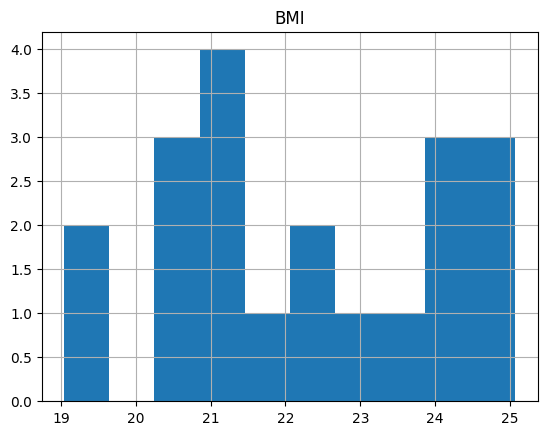

In [328]:
df.hist('BMI')

<Axes: >

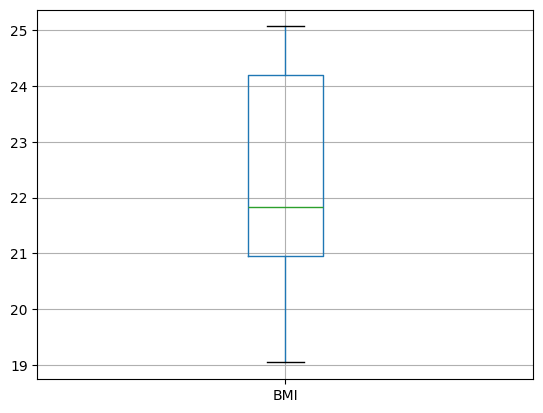

In [329]:
df.boxplot('BMI')

In [ ]:
# df['duration1'] > df['duration2']

### Deskriptive Statistik

In [330]:
df.describe()

,Weight,Height,BMI
count,20.000000,20.000000,20.000000
mean,69.350000,176.000000,22.247647
std,10.938945,8.006576,1.907687
min,52.500000,160.000000,19.045440
25%,60.325000,170.250000,20.956756
50%,66.600000,177.000000,21.837332
75%,78.750000,181.250000,24.191875
max,90.500000,190.000000,25.069252


In [342]:
# df.mean() # Fehler, auch nicht-numerische Spalten werden zu mitteln versucht
print(f'Mean: {df['Height'].mean()}')
print(f'Median: {df['Height'].median()}')
print(f'Mode: {df['Height'].mode()}')

for column in df.columns:
    col = df[column]
    if col.dtype == np.float64:
        print(f'Mean: {col.mean()}')
        print(f'Median: {col.median()}')
        print(f'Mode: {col.mode()}')


Mean: 176.0
Median: 177.0
Mode: 0    177.0
Name: Height, dtype: float64
Mean: 69.35
Median: 66.6
Mode: 0    66.6
Name: Weight, dtype: float64
Mean: 176.0
Median: 177.0
Mode: 0    177.0
Name: Height, dtype: float64
Mean: 22.247646957637638
Median: 21.837332358567732
Mode: 0     19.045440
1     19.311181
2     20.495868
3     20.507812
4     20.576281
5     21.083581
6     21.152211
7     21.237304
8     21.258259
9     21.500517
10    22.174148
11    22.465306
12    22.850650
13    23.844449
14    24.175086
15    24.242241
16    24.259259
17    24.722353
18    24.981738
19    25.069252
Name: BMI, dtype: float64
